In [6]:
import pandas as pd
# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv('../6.Data/kaggle_b2_fraud_train_v4.csv')
df[['is_vpn', 'target_is_fraud']].target_is_fraud.value_counts()

target_is_fraud
0    146223
1     13777
Name: count, dtype: int64

     Groupe  Fraude (%)  Pas fraude (%)     Total
0  Sans VPN         7.4            92.6  147149.0
1  Avec VPN        22.4            77.6   12851.0


C:\Users\yannc\AppData\Local\Temp\ipykernel_13808\4038181957.py:99: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yannc\AppData\Local\Temp\ipykernel_13808\4038181957.py:100: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("vpn_fraud_chart.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
C:\Users\yannc\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


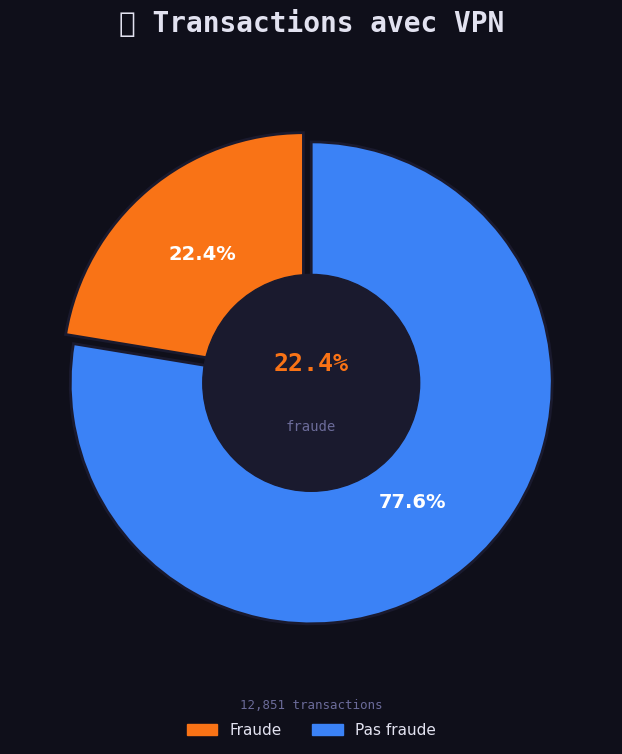


✅ Graphique sauvegardé : vpn_fraud_chart.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ──────────────────────────────────────────────
# 🔧 CHARGE TON DATAFRAME ICI
# ──────────────────────────────────────────────
# Option 1 - CSV :
# df = pd.read_csv("ton_fichier.csv")

# Option 2 - Parquet :
# df = pd.read_parquet("ton_fichier.parquet")

# Option 3 - Excel :
# df = pd.read_excel("ton_fichier.xlsx")

# Pour tester sans fichier, décommente ces lignes :
import numpy as np
np.random.seed(42)

# ──────────────────────────────────────────────


# ── Calcul des pourcentages ──
def get_pcts(group):
    total = len(group)
    fraud = group["target_is_fraud"].sum()
    return pd.Series({
        "Fraude (%)": round(fraud / total * 100, 1),
        "Pas fraude (%)": round((total - fraud) / total * 100, 1),
        "Total": total,
    })

stats = df.groupby("is_vpn").apply(get_pcts).reset_index()
stats["Groupe"] = stats["is_vpn"].map({0: "Sans VPN", 1: "Avec VPN"})

print(stats[["Groupe", "Fraude (%)", "Pas fraude (%)", "Total"]])

# ── Couleurs ──
FRAUD_COLOR  = "#f97316"   # orange
LEGIT_COLOR  = "#3b82f6"   # bleu
BG_COLOR     = "#0f0f1a"
CARD_COLOR   = "#1a1a2e"
TEXT_COLOR   = "#e2e2f0"
MUTED_COLOR  = "#6b6b99"

# ── Filtre : uniquement les utilisateurs VPN ──
row = stats[stats["is_vpn"] == 1].iloc[0]

# ── Figure ──
fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
fig.suptitle("🔒 Transactions avec VPN", fontsize=20, fontweight="bold",
             color=TEXT_COLOR, y=1.02, fontfamily="monospace")

ax.set_facecolor(CARD_COLOR)
for spine in ax.spines.values():
    spine.set_visible(False)

sizes  = [row["Fraude (%)"], row["Pas fraude (%)"]]
colors = [FRAUD_COLOR, LEGIT_COLOR]

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    explode=(0.05, 0),
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.65,
    wedgeprops=dict(linewidth=2, edgecolor=CARD_COLOR),
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight("bold")
    at.set_color("white")

# Donut
centre = plt.Circle((0, 0), 0.45, color=CARD_COLOR)
ax.add_patch(centre)

# Texte centre
ax.text(0, 0.08, f"{row['Fraude (%)']:.1f}%", ha="center", va="center",
        fontsize=18, fontweight="bold", color=FRAUD_COLOR, fontfamily="monospace")
ax.text(0, -0.18, "fraude", ha="center", va="center",
        fontsize=10, color=MUTED_COLOR, fontfamily="monospace")

ax.text(0, -1.35, f"{int(row['Total']):,} transactions",
        ha="center", fontsize=9, color=MUTED_COLOR, fontfamily="monospace",
        transform=ax.transData)

# ── Légende ──
legend_patches = [
    mpatches.Patch(color=FRAUD_COLOR, label="Fraude"),
    mpatches.Patch(color=LEGIT_COLOR, label="Pas fraude"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           frameon=False, fontsize=11,
           labelcolor=TEXT_COLOR, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("vpn_fraud_chart.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("\n✅ Graphique sauvegardé : vpn_fraud_chart.png")